<a href="https://colab.research.google.com/github/Azeotroph/Machine-Learning/blob/main/Landslide_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upgrade pip and install required packages
!pip install --upgrade pip
!pip install torch torchvision torchaudio
!pip install segmentation-models-pytorch albumentations
!pip install xarray rioxarray zarr

# Clone the GitHub repository (if you wish to refer to its structure)
!git clone https://github.com/iprapas/landslide-sar-unet.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 155.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 M

In [ ]:
!wget -O landslide_dataset.zip "https://zenodo.org/records/7248056/files/hokkaido_japan.zip?download=1"

--2025-04-04 06:31:54--  https://zenodo.org/records/7248056/files/hokkaido_japan.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.48.194, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10772695360 (10G) [application/octet-stream]
Saving to: ‘landslide_dataset.zip’

landslide_dataset.z 100%[===================>]  10.03G  17.5MB/s    in 9m 13s  

2025-04-04 06:41:07 (18.6 MB/s) - ‘landslide_dataset.zip’ saved [10772695360/10772695360]



In [ ]:
!unzip -q landslide_dataset.zip -d ./hokkaido_japan
!ls -R ./hokkaido_japan

./hokkaido_japan:
hokkaido_japan.zarr

./hokkaido_japan/hokkaido_japan.zarr:
band		   reactivated_landslides	   sar:resolution_azimuth
constellation	   s1:datatake_id		   sar:resolution_range
dem		   s1:instrument_configuration_ID  sat:absolute_orbit
dem_aspect	   s1:orbit_source		   sat:orbit_state
dem_curvature	   s1:processing_level		   sat:platform_international_designator
dem_slope_radians  s1:product_timeliness	   sat:relative_orbit
dem_slope_riserun  s1:resolution		   spatial_ref
description	   s1:slice_number		   start_datetime
end_datetime	   s1:total_slices		   timepair
epsg		   sar:center_frequency		   timestep
extraction_mask    sar:frequency_band		   title
id		   sar:instrument_mode		   topophase_cor_0
landslides	   sar:looks_azimuth		   topophase_cor_1
los_rdr_0	   sar:looks_equivalent_number	   topophase_flat_imag
los_rdr_1	   sar:looks_range		   topophase_flat_real
old_landslides	   sar:observation_direction	   vh
phsig_cor	   sar:pixel_spacing_azimuth	   vv
platform	  

In [ ]:
!pip install zarr

In [ ]:
import xarray as xr

# Open the Zarr datacube from the specified folder
ds = xr.open_zarr("./hokkaido_japan/hokkaido_japan.zarr")
print(ds)

<xarray.Dataset> Size: 27GB
Dimensions:                                (y: 5382, x: 4398, timestep: 26,
                                            timepair: 16)
Coordinates: (12/38)
    band                                   <U2 8B ...
    constellation                          <U10 40B ...
    description                            <U171 684B ...
    end_datetime                           (timestep) <U1 104B dask.array<chunksize=(1,), meta=np.ndarray>
    epsg                                   int64 8B ...
    id                                     (timestep) <U1 104B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                     ...
    start_datetime                         (timestep) <U1 104B dask.array<chunksize=(1,), meta=np.ndarray>
  * timepair                               (timepair) <U31 2kB '20180707T2041...
  * timestep                               (timestep) <U15 2kB '20180707T2041...
    title                                  <U39 156B ...
  * x

In [ ]:
print(ds.data_vars)

Data variables:
    dem                     (y, x) float64 189MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    dem_aspect              (y, x) float32 95MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    dem_curvature           (y, x) float32 95MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    dem_slope_radians       (y, x) float32 95MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    dem_slope_riserun       (y, x) float32 95MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    extraction_mask         (y, x) float64 189MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    landslides              (y, x) float64 189MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    los_rdr_0               (timepair, y, x) float64 3GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    los_rdr_1               (timepair, y, x) float64 3GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    old_landslides          (y, x) float64 189MB dask.array<chunksize=(512,

In [ ]:
import xarray as xr

# Open the Zarr datacube
ds = xr.open_zarr("./hokkaido_japan/hokkaido_japan.zarr")

# Load SAR channels – using the first timestep as an example.
vv = ds['vv'].isel(timestep=0).compute()  # shape: (y, x)
vh = ds['vh'].isel(timestep=0).compute()  # shape: (y, x)

# Load DEM-related channels
dem = ds['dem'].compute()                     # shape: (y, x)
dem_aspect = ds['dem_aspect'].compute()         # shape: (y, x)
dem_curvature = ds['dem_curvature'].compute()   # shape: (y, x)
dem_slope_radians = ds['dem_slope_radians'].compute()  # shape: (y, x)
dem_slope_riserun = ds['dem_slope_riserun'].compute()  # shape: (y, x)

# Load the landslide labels (target)
landslides = ds['landslides'].compute()         # shape: (y, x)

In [ ]:
import numpy as np

# Stack the channels: output shape will be (channels, y, x)
input_array = np.stack([vv, vh, dem, dem_aspect, dem_curvature, dem_slope_radians, dem_slope_riserun], axis=0)
print("Input array shape:", input_array.shape)


Input array shape: (7, 5382, 4398)


In [ ]:
landslides = ds['landslides'].compute()
print("Landslides shape:", landslides.shape)
print("Landslides dtype:", landslides.dtype)

Landslides shape: (5382, 4398)
Landslides dtype: float64


In [ ]:
landslides = landslides.astype(np.float64)

In [ ]:
print("Type:", type(landslides))
print("Shape:", landslides.shape)
print("Dtype:", landslides.dtype)

Type: <class 'xarray.core.dataarray.DataArray'>
Shape: (5382, 4398)
Dtype: float64


In [ ]:
import numpy as np

# Convert the xarray DataArray to a NumPy array
landslides_np = landslides.values
print("Converted type:", type(landslides_np))
print("Converted shape:", landslides_np.shape)

# Now, expand the dimensions to add a channel axis
landslides_expanded = landslides_np[None, ...]
print("Expanded shape:", landslides_expanded.shape)  # Expected output: (1, 5382, 4398)

Converted type: <class 'numpy.ndarray'>
Converted shape: (5382, 4398)
Expanded shape: (1, 5382, 4398)


In [ ]:
def extract_chips_multichannel(arr, chip_size=128, stride=128):
    c, h, w = arr.shape
    chips = []
    for row in range(0, h - chip_size + 1, stride):
        for col in range(0, w - chip_size + 1, stride):
            chip = arr[:, row:row+chip_size, col:col+chip_size]
            chips.append(chip)
    return chips


In [ ]:
chips_target = extract_chips_multichannel(landslides_expanded, chip_size=128, stride=128)
print(f"Extracted {len(chips_target)} target chips.")

Extracted 1428 target chips.


In [ ]:
import numpy as np

# Convert each xarray DataArray to NumPy
vv_0 = ds['vv'].isel(timestep=0).values  # shape (5382, 4398)
vh_0 = ds['vh'].isel(timestep=0).values
dem = ds['dem'].values
dem_aspect = ds['dem_aspect'].values
dem_curvature = ds['dem_curvature'].values
dem_slope_radians = ds['dem_slope_radians'].values
dem_slope_riserun = ds['dem_slope_riserun'].values

# Stack channels into a single array of shape (C, H, W)
input_array = np.stack(
    [vv_0, vh_0, dem, dem_aspect, dem_curvature, dem_slope_radians, dem_slope_riserun],
    axis=0
)
print("Input array shape:", input_array.shape)  # Expect (7, 5382, 4398)

Input array shape: (7, 5382, 4398)


In [ ]:
def extract_chips_multichannel(arr, chip_size=128, stride=128):
    """
    Extract non-overlapping chips from a multi-channel array of shape (C, H, W).
    """
    c, h, w = arr.shape
    chips = []
    for row in range(0, h - chip_size + 1, stride):
        for col in range(0, w - chip_size + 1, stride):
            chip = arr[:, row:row+chip_size, col:col+chip_size]
            chips.append(chip)
    return chips

chips_input = extract_chips_multichannel(input_array, chip_size=128, stride=128)
print("Number of input chips:", len(chips_input))
print("Shape of one input chip:", chips_input[0].shape)  # (7, 128, 128)

Number of input chips: 1428
Shape of one input chip: (7, 128, 128)


In [ ]:
import random

# Combine input & target into a single list of pairs
paired_chips = list(zip(chips_input, chips_target))

# Shuffle
random.shuffle(paired_chips)

# Split
train_size = int(0.8 * len(paired_chips))
val_size = int(0.1 * len(paired_chips))
test_size = len(paired_chips) - train_size - val_size

train_pairs = paired_chips[:train_size]
val_pairs = paired_chips[train_size:train_size+val_size]
test_pairs = paired_chips[train_size+val_size:]

print("Train:", len(train_pairs), "Val:", len(val_pairs), "Test:", len(test_pairs))

Train: 1142 Val: 142 Test: 144


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class LandslideDataset(Dataset):
    def __init__(self, pairs):
        """
        pairs: list of (input_chip, target_chip)
        where input_chip.shape == (C, 128, 128), target_chip.shape == (1, 128, 128)
        """
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        input_chip, target_chip = self.pairs[idx]

        # Convert to float tensors
        input_tensor = torch.tensor(input_chip, dtype=torch.float32)
        target_tensor = torch.tensor(target_chip, dtype=torch.float32)

        return input_tensor, target_tensor

# Create dataset objects
train_dataset = LandslideDataset(train_pairs)
val_dataset = LandslideDataset(val_pairs)
test_dataset = LandslideDataset(test_pairs)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [ ]:
import torch
from torch.utils.data import Dataset

class LandslideDataset(Dataset):
    def __init__(self, inputs, targets, transform=None):
        """
        inputs: list of NumPy arrays of shape (C, H, W)
        targets: list of NumPy arrays of shape (1, H, W)
        transform: optional function/transform for data augmentation
        """
        self.inputs = inputs
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = self.inputs[idx]  # shape (C, H, W)
        y = self.targets[idx] # shape (1, H, W)

        # Convert to PyTorch tensors
        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.from_numpy(y).float()  # or .long(), depending on your loss

        # Optionally apply transforms/augmentations
        if self.transform:
            # e.g., self.transform could be an albumentations pipeline
            # but typically you'd pass in H,W,C. So adapt as needed.
            pass

        return x_tensor, y_tensor

In [ ]:
import segmentation_models_pytorch as smp

ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
IN_CHANNELS = 7  # same as the number of stacked channels
CLASSES = 1      # binary segmentation

model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=CLASSES,
)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()  # For binary segmentation
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        # For BCEWithLogitsLoss, targets should be shape (B, 1, H, W)
        # If your target is shape (B, 1, H, W) that’s fine. Otherwise unsqueeze if needed.

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = validate_one_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

Epoch [1/20]  Train Loss: nan  Val Loss: nan
Epoch [2/20]  Train Loss: nan  Val Loss: nan
Epoch [3/20]  Train Loss: nan  Val Loss: nan
Epoch [4/20]  Train Loss: nan  Val Loss: nan
Epoch [5/20]  Train Loss: nan  Val Loss: nan
Epoch [6/20]  Train Loss: nan  Val Loss: nan
Epoch [7/20]  Train Loss: nan  Val Loss: nan
Epoch [8/20]  Train Loss: nan  Val Loss: nan
Epoch [9/20]  Train Loss: nan  Val Loss: nan
Epoch [10/20]  Train Loss: nan  Val Loss: nan
Epoch [11/20]  Train Loss: nan  Val Loss: nan
Epoch [12/20]  Train Loss: nan  Val Loss: nan
Epoch [13/20]  Train Loss: nan  Val Loss: nan
Epoch [14/20]  Train Loss: nan  Val Loss: nan
Epoch [15/20]  Train Loss: nan  Val Loss: nan
Epoch [16/20]  Train Loss: nan  Val Loss: nan
Epoch [17/20]  Train Loss: nan  Val Loss: nan
Epoch [18/20]  Train Loss: nan  Val Loss: nan
Epoch [19/20]  Train Loss: nan  Val Loss: nan
Epoch [20/20]  Train Loss: nan  Val Loss: nan


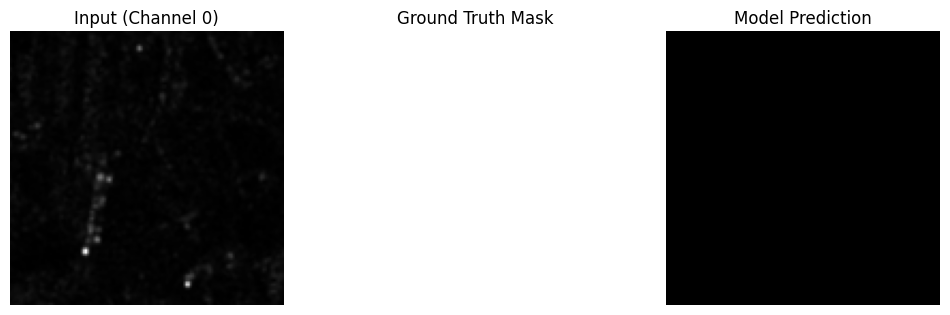

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def predict(model, x):
    model.eval()
    with torch.no_grad():
        x = x.unsqueeze(0).to(device)  # Add batch dimension
        logits = model(x)             # shape [1, 1, H, W]
        probs = torch.sigmoid(logits) # Convert to [0..1]
        pred_mask = (probs > 0.5).float()
    return pred_mask.cpu().squeeze(0)  # shape [1, H, W] -> remove batch dim

# Example: get a sample from val_dataset
sample_input, sample_target = val_dataset[0]  # shape (C, H, W) and (1, H, W)
prediction = predict(model, sample_input)      # shape (1, H, W)

# Visualize
plt.figure(figsize=(12, 4))

# Channel 0 of input, if you want to see something
plt.subplot(1,3,1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0].numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(sample_target[0].numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Model Prediction")
plt.imshow(prediction[0].numpy(), cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
print("Mask min:", sample_target.min().item())
print("Mask max:", sample_target.max().item())
print("Mask unique values:", torch.unique(sample_target))


Mask min: nan
Mask max: nan
Mask unique values: tensor([nan, nan, nan,  ..., nan, nan, nan])


In [ ]:
import numpy as np

# Suppose your landslides array is still an xarray.DataArray
landslides_da = ds['landslides']

# Convert to NumPy
landslides_np = landslides_da.values

# Count how many NaNs
nan_count = np.isnan(landslides_np).sum()
print("Number of NaN values in mask:", nan_count)

Number of NaN values in mask: 23206731


In [ ]:
landslides_filled = np.nan_to_num(landslides_np, nan=0.0)
print("New mask min:", landslides_filled.min())
print("New mask max:", landslides_filled.max())
print("Unique values:", np.unique(landslides_filled))

New mask min: 0.0
New mask max: 1.0
Unique values: [0. 1.]


In [ ]:
# Expand dimensions to (1, height, width)
landslides_expanded = landslides_filled[None, ...]

# Extract chips
chips_target = extract_chips_multichannel(
    landslides_expanded,
    chip_size=128,
    stride=128
)

In [ ]:
sample_input, sample_target = val_dataset[50]  # pick a different index
pred_mask = predict(model, sample_input)
# ... then plot again ...

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x = x.to(device)  # Make sure device is defined globally (e.g., device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(device)

        optimizer.zero_grad()  # Correct usage: calling the zero_grad() method
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()       # Correct usage: calling the step() method

        running_loss += loss.item() * x.size(0)
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


In [ ]:
num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    # Append the scalar loss values to your lists
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}")


Epoch 1/10 | Train Loss: nan | Val Loss: nan
Epoch 2/10 | Train Loss: nan | Val Loss: nan
Epoch 3/10 | Train Loss: nan | Val Loss: nan
Epoch 4/10 | Train Loss: nan | Val Loss: nan
Epoch 5/10 | Train Loss: nan | Val Loss: nan
Epoch 6/10 | Train Loss: nan | Val Loss: nan
Epoch 7/10 | Train Loss: nan | Val Loss: nan
Epoch 8/10 | Train Loss: nan | Val Loss: nan
Epoch 9/10 | Train Loss: nan | Val Loss: nan
Epoch 10/10 | Train Loss: nan | Val Loss: nan


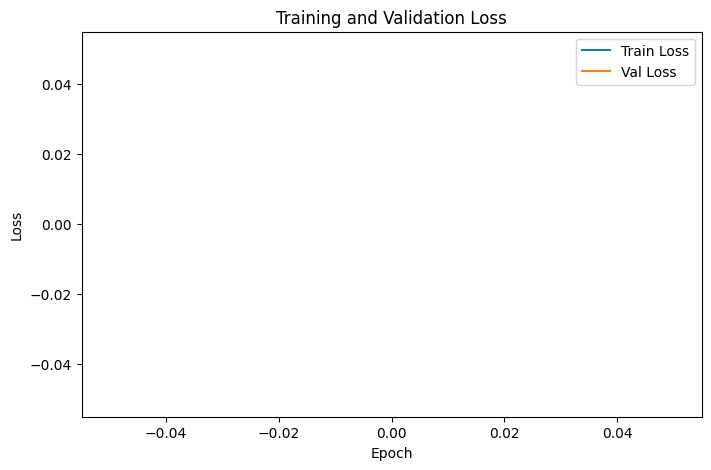

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
print("train_losses:", train_losses)
print("val_losses:", val_losses)


train_losses: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
val_losses: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [ ]:
import numpy as np

# Example: after you load vv and vh from ds['vv'] / ds['vh'] for the first timestep
vv_data = ds['vv'].isel(timestep=0).values  # shape: (H, W)
vh_data = ds['vh'].isel(timestep=0).values  # shape: (H, W)

# Log-transform: log1p(x) = log(1 + x), safe for 0 or positive data
vv_log = np.log1p(vv_data)
vh_log = np.log1p(vh_data)

# Optional: standardize each channel to mean=0, std=1
# (This helps if the dynamic range is large or unbalanced.)
vv_mean, vv_std = vv_log.mean(), vv_log.std()
vv_norm = (vv_log - vv_mean) / (vv_std + 1e-7)

vh_mean, vh_std = vh_log.mean(), vh_log.std()
vh_norm = (vh_log - vh_mean) / (vh_std + 1e-7)

# Similarly, load your DEM layers and decide if you want to standardize them.
# e.g. dem, dem_aspect, dem_curvature, dem_slope_radians, dem_slope_riserun
dem_data = ds['dem'].values  # shape (H, W)
# ... repeat if you want to log-transform or standardize ...


In [ ]:
# Example stacking: (C, H, W)
input_array = np.stack([
    vv_norm,
    vh_norm,
    dem_data,
    ds['dem_aspect'].values,
    ds['dem_curvature'].values,
    ds['dem_slope_radians'].values,
    ds['dem_slope_riserun'].values
], axis=0)

print("Input array shape:", input_array.shape)  # (7, H, W)

# Load or fill NaNs in the landslide mask
landslides_np = ds['landslides'].values
landslides_np = np.nan_to_num(landslides_np, nan=0.0)  # Fill NaN with 0

# Expand mask to shape (1, H, W)
mask_array = landslides_np[None, ...]

print("Mask array shape:", mask_array.shape)  # (1, H, W)


Input array shape: (7, 5382, 4398)
Mask array shape: (1, 5382, 4398)


In [ ]:
def extract_chips_multichannel(arr, chip_size=128, stride=128):
    """
    arr: (C, H, W)
    returns list of arrays each shape (C, chip_size, chip_size)
    """
    c, h, w = arr.shape
    chips = []
    for row in range(0, h - chip_size + 1, stride):
        for col in range(0, w - chip_size + 1, stride):
            chip = arr[:, row:row+chip_size, col:col+chip_size]
            chips.append(chip)
    return chips

chips_input = extract_chips_multichannel(input_array, 128, 128)   # shape (C, 128, 128)
chips_mask  = extract_chips_multichannel(mask_array, 128, 128)    # shape (1, 128, 128)

print("Number of input chips:", len(chips_input))
print("Number of mask chips:", len(chips_mask))


Number of input chips: 1428
Number of mask chips: 1428


In [ ]:
import random

paired = list(zip(chips_input, chips_mask))
random.shuffle(paired)

train_size = int(0.7 * len(paired))  # 70% train
val_size   = int(0.15 * len(paired)) # 15% val
test_size  = len(paired) - train_size - val_size

train_pairs = paired[:train_size]
val_pairs   = paired[train_size:train_size+val_size]
test_pairs  = paired[train_size+val_size:]

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")


Train: 999 | Val: 214 | Test: 215


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class LandslideDataset(Dataset):
    def __init__(self, pairs):
        """
        pairs: list of (input_chip, mask_chip)
        input_chip.shape: (C, 128, 128)
        mask_chip.shape:  (1, 128, 128)
        """
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        x, y = self.pairs[idx]  # x: (C, 128, 128), y: (1, 128, 128)
        x_tensor = torch.tensor(x, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        return x_tensor, y_tensor

# Build datasets
train_dataset = LandslideDataset(train_pairs)
val_dataset   = LandslideDataset(val_pairs)
test_dataset  = LandslideDataset(test_pairs)

# Build loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)


In [ ]:
import segmentation_models_pytorch as smp
import torch.optim as optim
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Suppose we have 7 channels: in_channels=7
model = smp.Unet(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    in_channels=7,  # or 8 if you included an extra channel
    classes=1       # for binary segmentation
).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.1,
    patience=10,
    threshold=1e-4
)

# The paper mentions "a standard cross-entropy loss" but for binary masks,
# BCEWithLogitsLoss is effectively the same for a single class:
criterion = nn.BCEWithLogitsLoss()


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)  # shape [B, 1, 128, 128]
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(loader.dataset)

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
    return running_loss / len(loader.dataset)

num_epochs = 100
train_losses = []
val_losses   = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate_one_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}")


Epoch [1/100]  Train Loss: 0.1098  Val Loss: 0.0735
Epoch [2/100]  Train Loss: 0.0961  Val Loss: 0.0791
Epoch [3/100]  Train Loss: 0.0966  Val Loss: 0.0741
Epoch [4/100]  Train Loss: 0.0934  Val Loss: 0.0941
Epoch [5/100]  Train Loss: 0.0953  Val Loss: 0.0683
Epoch [6/100]  Train Loss: 0.0934  Val Loss: 0.0725
Epoch [7/100]  Train Loss: 0.0924  Val Loss: 0.0706
Epoch [8/100]  Train Loss: 0.0916  Val Loss: 0.0677
Epoch [9/100]  Train Loss: 0.0898  Val Loss: 0.0649
Epoch [10/100]  Train Loss: 0.0947  Val Loss: 0.0775
Epoch [11/100]  Train Loss: 0.0987  Val Loss: 0.0912
Epoch [12/100]  Train Loss: 0.0974  Val Loss: 0.0711
Epoch [13/100]  Train Loss: 0.0933  Val Loss: 0.0712
Epoch [14/100]  Train Loss: 0.0920  Val Loss: 0.0695
Epoch [15/100]  Train Loss: 0.0916  Val Loss: 0.0689
Epoch [16/100]  Train Loss: 0.0922  Val Loss: 0.0685
Epoch [17/100]  Train Loss: 0.0927  Val Loss: 0.0840
Epoch [18/100]  Train Loss: 0.0913  Val Loss: 0.0709
Epoch [19/100]  Train Loss: 0.0900  Val Loss: 0.0699
Ep

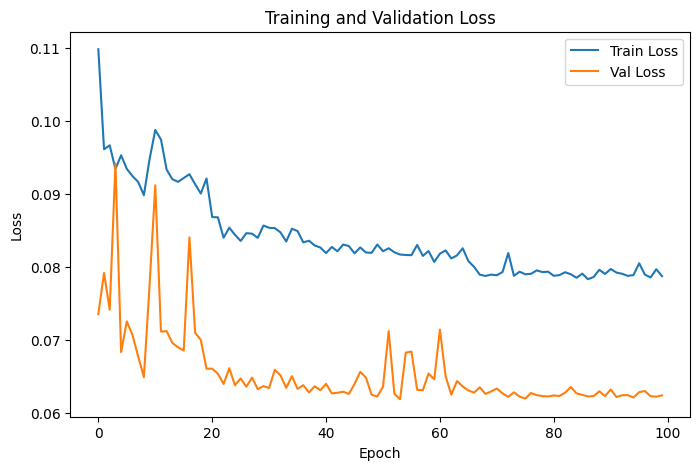

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

def evaluate_auprc(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)  # shape [B, 1, 128, 128]

            # Flatten predictions & labels
            all_preds.append(probs.cpu().numpy().ravel())
            all_labels.append(targets.cpu().numpy().ravel())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    precision, recall, _ = precision_recall_curve(all_labels, all_preds)
    auprc_val = auc(recall, precision)
    return auprc_val

# Example usage on the validation set
val_auprc = evaluate_auprc(model, val_loader)
print("Validation AUPRC:", val_auprc)


Validation AUPRC: 0.07150814677392557


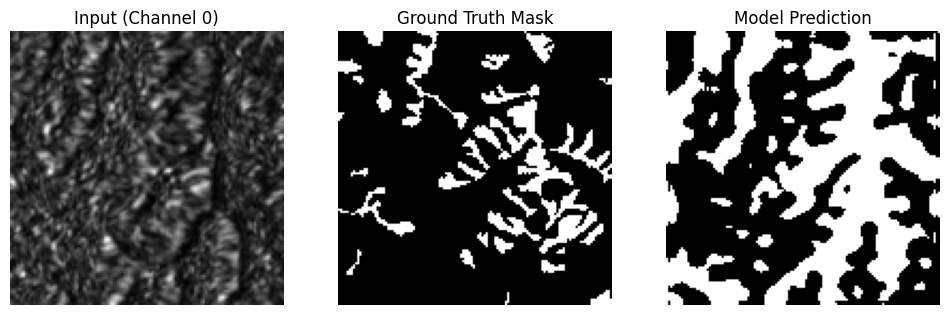

In [ ]:
sample_input, sample_target = val_dataset[0]  # shape (C, 128, 128) & (1, 128, 128)

model.eval()
with torch.no_grad():
    inp = sample_input.unsqueeze(0).to(device)  # shape [1, C, 128, 128]
    out = model(inp)                            # shape [1, 1, 128, 128]
    prob = torch.sigmoid(out)
    pred_mask = (prob > 0.05).float()

pred_mask_np = pred_mask.cpu().squeeze(0).squeeze(0).numpy()  # shape [128, 128]
target_np = sample_target.squeeze(0).numpy()                  # shape [128, 128]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0], cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(target_np, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Model Prediction")
plt.imshow(pred_mask_np, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
full_mask = ds['landslides'].values
full_mask = np.nan_to_num(full_mask, nan=0)
print("Min:", full_mask.min(), "Max:", full_mask.max(), "Unique:", np.unique(full_mask))
print("Sum of mask:", full_mask.sum())


Min: 0.0 Max: 1.0 Unique: [0. 1.]
Sum of mask: 463305.0


In [ ]:
for i, (inp, msk) in enumerate(val_dataset):
    if msk.sum() > 0:
        print("Found positive patch at index", i)

Found positive patch at index 0
Found positive patch at index 1
Found positive patch at index 2
Found positive patch at index 4
Found positive patch at index 11
Found positive patch at index 13
Found positive patch at index 17
Found positive patch at index 18
Found positive patch at index 22
Found positive patch at index 28
Found positive patch at index 29
Found positive patch at index 32
Found positive patch at index 44
Found positive patch at index 47
Found positive patch at index 53
Found positive patch at index 65
Found positive patch at index 70
Found positive patch at index 73
Found positive patch at index 74
Found positive patch at index 91
Found positive patch at index 97
Found positive patch at index 103
Found positive patch at index 111
Found positive patch at index 113
Found positive patch at index 119
Found positive patch at index 122
Found positive patch at index 123
Found positive patch at index 134
Found positive patch at index 137
Found positive patch at index 139
Found

In [ ]:
# Search for a patch with at least one positive pixel
positive_idx = None
for i, (inp, msk) in enumerate(val_dataset):
    # msk is shape (1, 128, 128). Summation tells how many '1's are in the mask.
    if msk.sum() > 0:
        positive_idx = i
        print(f"Found a positive patch at index {i}, mask sum = {msk.sum().item()}")
        break

if positive_idx is not None:
    sample_input, sample_target = val_dataset[positive_idx]
    print("Visualizing a patch that actually has landslide pixels.")
else:
    print("No positive patch found in validation dataset!")


Found a positive patch at index 0, mask sum = 2516.0
Visualizing a patch that actually has landslide pixels.


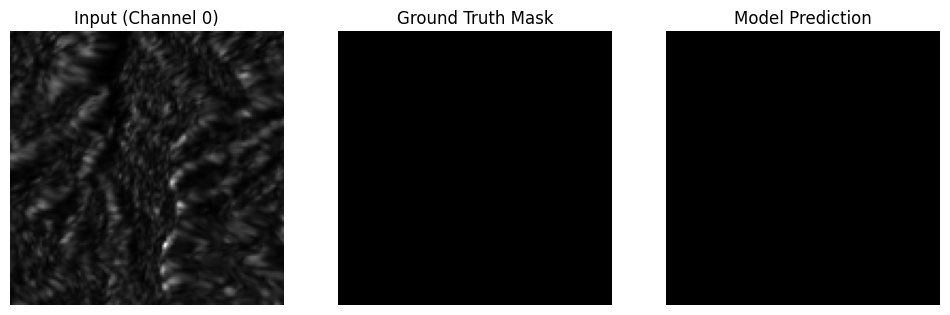

Ground truth mask sum: 0.0
Prediction mask sum: 0.0


In [ ]:
sample_input, sample_target = val_dataset[10]

# Run inference on the patch
pred_mask = predict(model, sample_input)

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1) The first channel of your input (e.g., VV)
plt.subplot(1, 3, 1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 2) The ground-truth mask
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(sample_target[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 3) The model's predicted mask
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(pred_mask[0].cpu().numpy(), cmap='gray')
plt.axis("off")

plt.show()

# Optionally, check min/max/unique values in the ground truth and prediction
print("Ground truth mask sum:", sample_target.sum().item())
print("Prediction mask sum:", pred_mask.sum().item())


Found 44 positive patches in val_dataset.


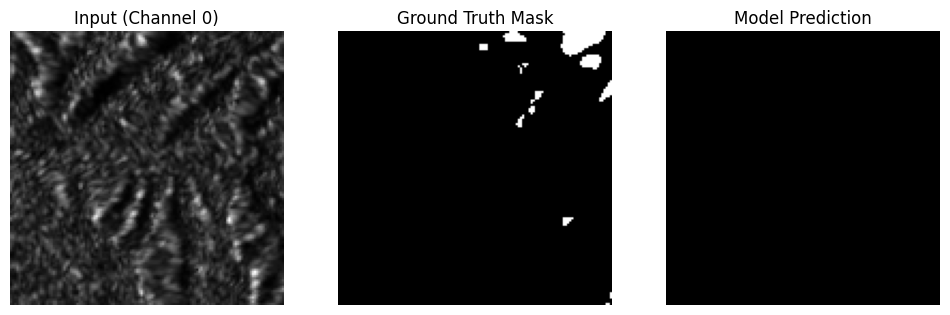

Ground truth mask sum: 365.0
Prediction mask sum: 0.0


In [ ]:
positive_indices = []
for i, (inp, msk) in enumerate(val_dataset):
    if msk.sum() > 0:
        positive_indices.append(i)

print(f"Found {len(positive_indices)} positive patches in val_dataset.")

# Visualize a few of them
for idx in positive_indices[:5]:  # e.g., the first 5 positive patches
    sample_input, sample_target = val_dataset[idx]
    pred_mask = predict(model, sample_input)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1) The first channel of your input (e.g., VV)
plt.subplot(1, 3, 1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 2) The ground-truth mask
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(sample_target[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 3) The model's predicted mask
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(pred_mask[0].cpu().numpy(), cmap='gray')
plt.axis("off")

plt.show()

# Optionally, check min/max/unique values in the ground truth and prediction
print("Ground truth mask sum:", sample_target.sum().item())
print("Prediction mask sum:", pred_mask.sum().item())

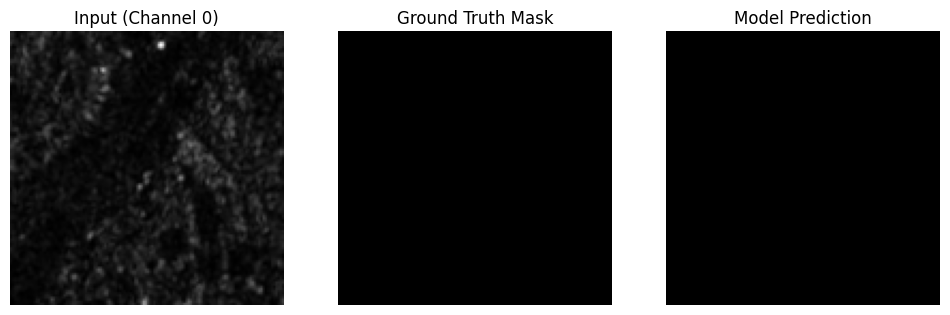

Ground truth mask sum: 0.0
Prediction mask sum: 0.0


In [ ]:
sample_input, sample_target = val_dataset[121]

# Run inference on the patch
pred_mask = predict(model, sample_input)

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1) The first channel of your input (e.g., VV)
plt.subplot(1, 3, 1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 2) The ground-truth mask
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(sample_target[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 3) The model's predicted mask
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(pred_mask[0].cpu().numpy(), cmap='gray')
plt.axis("off")

plt.show()

# Optionally, check min/max/unique values in the ground truth and prediction
print("Ground truth mask sum:", sample_target.sum().item())
print("Prediction mask sum:", pred_mask.sum().item())


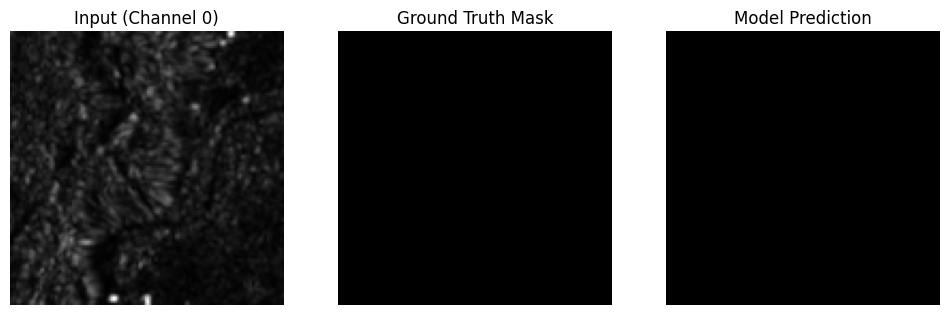

Ground truth mask sum: 0.0
Prediction mask sum: 0.0


In [ ]:
sample_input, sample_target = val_dataset[117]

# Run inference on the patch
pred_mask = predict(model, sample_input)

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1) The first channel of your input (e.g., VV)
plt.subplot(1, 3, 1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 2) The ground-truth mask
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(sample_target[0].cpu().numpy(), cmap='gray')
plt.axis("off")

# 3) The model's predicted mask
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(pred_mask[0].cpu().numpy(), cmap='gray')
plt.axis("off")

plt.show()

# Optionally, check min/max/unique values in the ground truth and prediction
print("Ground truth mask sum:", sample_target.sum().item())
print("Prediction mask sum:", pred_mask.sum().item())


In [ ]:
x = sample_input.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(x)         # [B, 1, H, W]
    probs = torch.sigmoid(output)
    print("Probs min:", probs.min().item(), "Probs max:", probs.max().item())


Probs min: 3.423636201205227e-07 Probs max: 0.09507059305906296


In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp

dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()

# Get one batch of (inputs, targets) from your DataLoader
inputs, targets = next(iter(train_loader))  # or val_loader
inputs = inputs.to(device)
targets = targets.to(device)

# Forward pass
outputs = model(inputs)

# Combined loss
loss = 0.5 * bce_loss(outputs, targets) + 0.5 * dice_loss(outputs, targets)
print("Combined Loss:", loss.item())


Combined Loss: 0.5951225757598877


In [ ]:
import torch
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

# 1) Create a combined loss
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()

def combined_loss(outputs, targets):
    return 0.5 * bce_loss(outputs, targets) + 0.5 * dice_loss(outputs, targets)

# 2) Redefine your training loop to use the combined loss
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = combined_loss(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)

# 3) In your main code:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs = 50
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss   = validate_one_epoch(model, val_loader, combined_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1/50, Train Loss: 0.4523, Val Loss: 0.4174
Epoch 2/50, Train Loss: 0.4314, Val Loss: 0.4255
Epoch 3/50, Train Loss: 0.4366, Val Loss: 0.4139
Epoch 4/50, Train Loss: 0.4489, Val Loss: 0.4231
Epoch 5/50, Train Loss: 0.4392, Val Loss: 0.4125
Epoch 6/50, Train Loss: 0.4390, Val Loss: 0.4154
Epoch 7/50, Train Loss: 0.4442, Val Loss: 0.4240
Epoch 8/50, Train Loss: 0.4483, Val Loss: 0.4123
Epoch 9/50, Train Loss: 0.4334, Val Loss: 0.4122
Epoch 10/50, Train Loss: 0.4516, Val Loss: 0.4154
Epoch 11/50, Train Loss: 0.4259, Val Loss: 0.4120
Epoch 12/50, Train Loss: 0.4714, Val Loss: 0.4112
Epoch 13/50, Train Loss: 0.4304, Val Loss: 0.4191
Epoch 14/50, Train Loss: 0.4284, Val Loss: 0.4147
Epoch 15/50, Train Loss: 0.4172, Val Loss: 0.4110
Epoch 16/50, Train Loss: 0.4230, Val Loss: 0.4132
Epoch 17/50, Train Loss: 0.4198, Val Loss: 0.4133
Epoch 18/50, Train Loss: 0.4337, Val Loss: 0.4105
Epoch 19/50, Train Loss: 0.4479, Val Loss: 0.4088
Epoch 20/50, Train Loss: 0.4277, Val Loss: 0.4109
Epoch 21/

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(loader.dataset)


Epoch 1/20 | Train Loss: 0.4225 | Val Loss: 0.4087
Epoch 2/20 | Train Loss: 0.4095 | Val Loss: 0.4052
Epoch 3/20 | Train Loss: 0.4277 | Val Loss: 0.4293
Epoch 4/20 | Train Loss: 0.4466 | Val Loss: 0.4089
Epoch 5/20 | Train Loss: 0.4283 | Val Loss: 0.4086
Epoch 6/20 | Train Loss: 0.4476 | Val Loss: 0.4129
Epoch 7/20 | Train Loss: 0.4192 | Val Loss: 0.4203
Epoch 8/20 | Train Loss: 0.4223 | Val Loss: 0.4094
Epoch 9/20 | Train Loss: 0.4096 | Val Loss: 0.4653
Epoch 10/20 | Train Loss: 0.4124 | Val Loss: 0.4057
Epoch 11/20 | Train Loss: 0.4240 | Val Loss: 0.4165
Epoch 12/20 | Train Loss: 0.4287 | Val Loss: 0.4115
Epoch 13/20 | Train Loss: 0.4200 | Val Loss: 0.4054
Epoch 14/20 | Train Loss: 0.4200 | Val Loss: 0.4062
Epoch 15/20 | Train Loss: 0.4090 | Val Loss: 0.4082
Epoch 16/20 | Train Loss: 0.4311 | Val Loss: 0.4063
Epoch 17/20 | Train Loss: 0.4138 | Val Loss: 0.4288
Epoch 18/20 | Train Loss: 0.4354 | Val Loss: 0.4118
Epoch 19/20 | Train Loss: 0.4315 | Val Loss: 0.4048
Epoch 20/20 | Train L

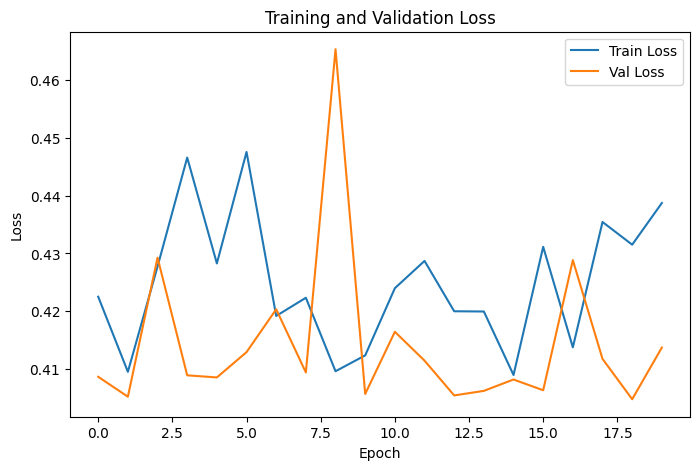

In [ ]:
# Retrain the model with the new combined loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs = 20  # Increase epochs if necessary
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, combined_loss)
    val_loss   = validate_one_epoch(model, val_loader, combined_loss)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Plot loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


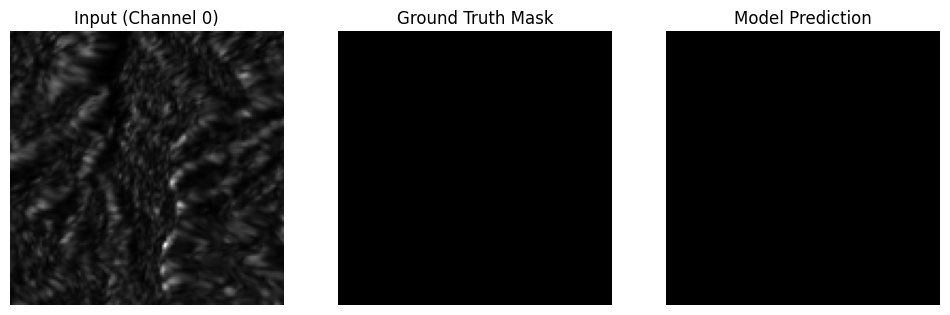

In [ ]:
import matplotlib.pyplot as plt

# Let's pick a sample patch from the validation dataset.
# For example, choose the patch at index 10 (or use a positive patch index you identified).
sample_input, sample_target = val_dataset[10]

# Use the predict function (which adds a batch dimension, runs the model, applies sigmoid, and thresholds)
pred_mask = predict(model, sample_input)

# Plotting the first channel of the input, the ground truth mask, and the prediction.
plt.figure(figsize=(12, 4))

# Plot the input image's first channel (e.g., the VV channel)
plt.subplot(1, 3, 1)
plt.title("Input (Channel 0)")
plt.imshow(sample_input[0].cpu().numpy(), cmap='gray')
plt.axis('off')

# Plot the ground truth mask
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(sample_target[0].cpu().numpy(), cmap='gray')
plt.axis('off')

# Plot the predicted mask
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(pred_mask[0].cpu().numpy(), cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
positive_indices = []
for i, (inp, msk) in enumerate(val_dataset):
    # msk.sum() is the total number of positive pixels in that patch
    if msk.sum() > 0:
        positive_indices.append(i)

print("Found these positive patch indices:", positive_indices)


Found these positive patch indices: [0, 1, 2, 4, 11, 13, 17, 18, 22, 28, 29, 32, 44, 47, 53, 65, 70, 73, 74, 91, 97, 103, 111, 113, 119, 122, 123, 134, 137, 139, 141, 142, 144, 150, 154, 157, 162, 163, 180, 182, 192, 198, 208, 212]


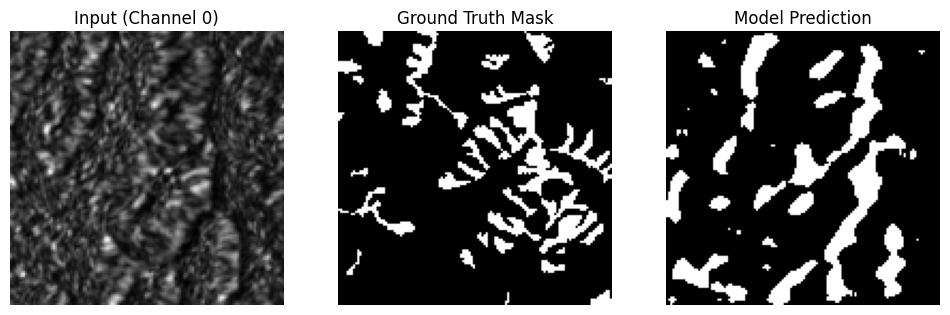

In [ ]:
if len(positive_indices) > 0:
    idx = positive_indices[0]  # or pick another index
    sample_input, sample_target = val_dataset[idx]

    # Predict and plot
    pred_mask = predict(model, sample_input)

    # Visualization
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input (Channel 0)")
    plt.imshow(sample_input[0].cpu().numpy(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(sample_target[0].cpu().numpy(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Model Prediction")
    plt.imshow(pred_mask[0].cpu().numpy(), cmap='gray')
    plt.axis("off")

    plt.show()
else:
    print("No positive patches found in val_dataset!")
